# Домашнее задание

Взять датасет либо на который была ссылка на семинаре (бразильский e-comm), либо из соревы m5 forecasting (там где ритейл) https://github.com/Mcompetitions/M5-methods/blob/master/M5-Competitors-Guide.pdf, выбрать от 2 до 10 (по желанию) артикулов с большой частотой продаж и количеством различных цен 10+.
Попробовать для каждого построить кривую эластичности и сказать, годится ли такой товар для промо или лучше в регулярку

Затем попробовать сделать прогноз количества продаж на отложенный период 3 способами:
1. Без учёта цены на отложенной периоде
2. С учётом цены на будущем периоде в модели
3. С помощью комбинации модель + кривая спроса от цены + знание будущей цены.   
Сравнить результаты и провести анализ. Что зашло или нет и почему? Что можно улучшить?


In [ ]:
impohttps://github.com/Mcompetitions/M5-methods/blob/master/M5-Competitors-Guide.pdfrt os
os.environ['KAGGLE_USERNAME'] = 'sacr1ficer'
os.environ['KAGGLE_KEY'] = '66367a7dfd0f7f7db2159acab04cf6d8'

In [6]:
# !kaggle competitions download -c m5-forecasting-accuracy
# !unzip m5-forecasting-accuracy

In [7]:
import pandas as pd
train_eval = pd.read_csv('./data/sales_train_evaluation.csv')
train_valid = pd.read_csv('./data/sales_train_validation.csv')
prices = pd.read_csv('./data/sell_prices.csv')

In [15]:
prices['item_id'].value_counts()[:20]

item_id
FOODS_3_587        2820
HOUSEHOLD_1_177    2820
HOUSEHOLD_2_283    2820
HOBBIES_1_337      2820
FOODS_1_032        2820
FOODS_2_294        2820
HOUSEHOLD_2_275    2820
HOBBIES_1_328      2820
FOODS_1_041        2820
FOODS_3_674        2820
FOODS_1_044        2820
HOBBIES_1_321      2820
HOBBIES_1_319      2820
HOBBIES_1_390      2820
HOBBIES_1_317      2820
HOUSEHOLD_1_179    2820
HOUSEHOLD_1_181    2820
FOODS_3_346        2820
HOBBIES_1_312      2820
FOODS_1_046        2820
Name: count, dtype: int64

In [52]:
items_all = prices['item_id'].value_counts()[:50].index.to_list()

In [53]:
items_all[:5]

['FOODS_3_587',
 'HOUSEHOLD_1_177',
 'HOUSEHOLD_2_283',
 'HOBBIES_1_337',
 'FOODS_1_032']

In [29]:
def get_prices(item: str):
    return prices.loc[prices['item_id'] == item]['sell_price'].to_numpy()
get_prices('FOODS_1_046')

array([1.  , 1.  , 1.  , ..., 0.98, 0.98, 0.98])

In [60]:
import numpy as np
variances = list(map(lambda item: np.var(get_prices(item)), items_all))

In [61]:
variances = np.array(variances)
variances[:10]

array([0.04044989, 0.21142922, 0.19500564, 0.00036679, 0.00026027,
       0.01939727, 0.03523254, 0.05624078, 0.019798  , 0.00119004])

In [67]:
idx = np.argsort(-variances)

In [68]:
variances[idx]

array([3.01374872e-01, 2.11429216e-01, 2.08121619e-01, 2.07097238e-01,
       1.95005639e-01, 8.73583396e-02, 7.29694771e-02, 6.47107254e-02,
       6.20264172e-02, 6.09427287e-02, 5.62407814e-02, 5.08362971e-02,
       4.52389301e-02, 4.19823822e-02, 4.17511802e-02, 4.04498944e-02,
       3.97200112e-02, 3.52325396e-02, 3.40213077e-02, 3.21356698e-02,
       2.88158555e-02, 2.59623879e-02, 2.51713196e-02, 2.43528383e-02,
       2.04123472e-02, 1.97979975e-02, 1.93972659e-02, 1.79654147e-02,
       1.48315927e-02, 1.32616618e-02, 1.27108809e-02, 1.01149230e-02,
       5.41858558e-03, 4.99092323e-03, 4.64876032e-03, 2.54976515e-03,
       1.78930259e-03, 1.69058921e-03, 1.55267314e-03, 1.19003526e-03,
       7.15013380e-04, 4.05906280e-04, 4.04707811e-04, 3.66787184e-04,
       3.08510588e-04, 2.77359288e-04, 2.60271415e-04, 2.25710729e-04,
       4.81377949e-06, 4.93038066e-32])

In [70]:
items_all = np.array(items_all)

In [71]:
items = items_all[idx][:20]

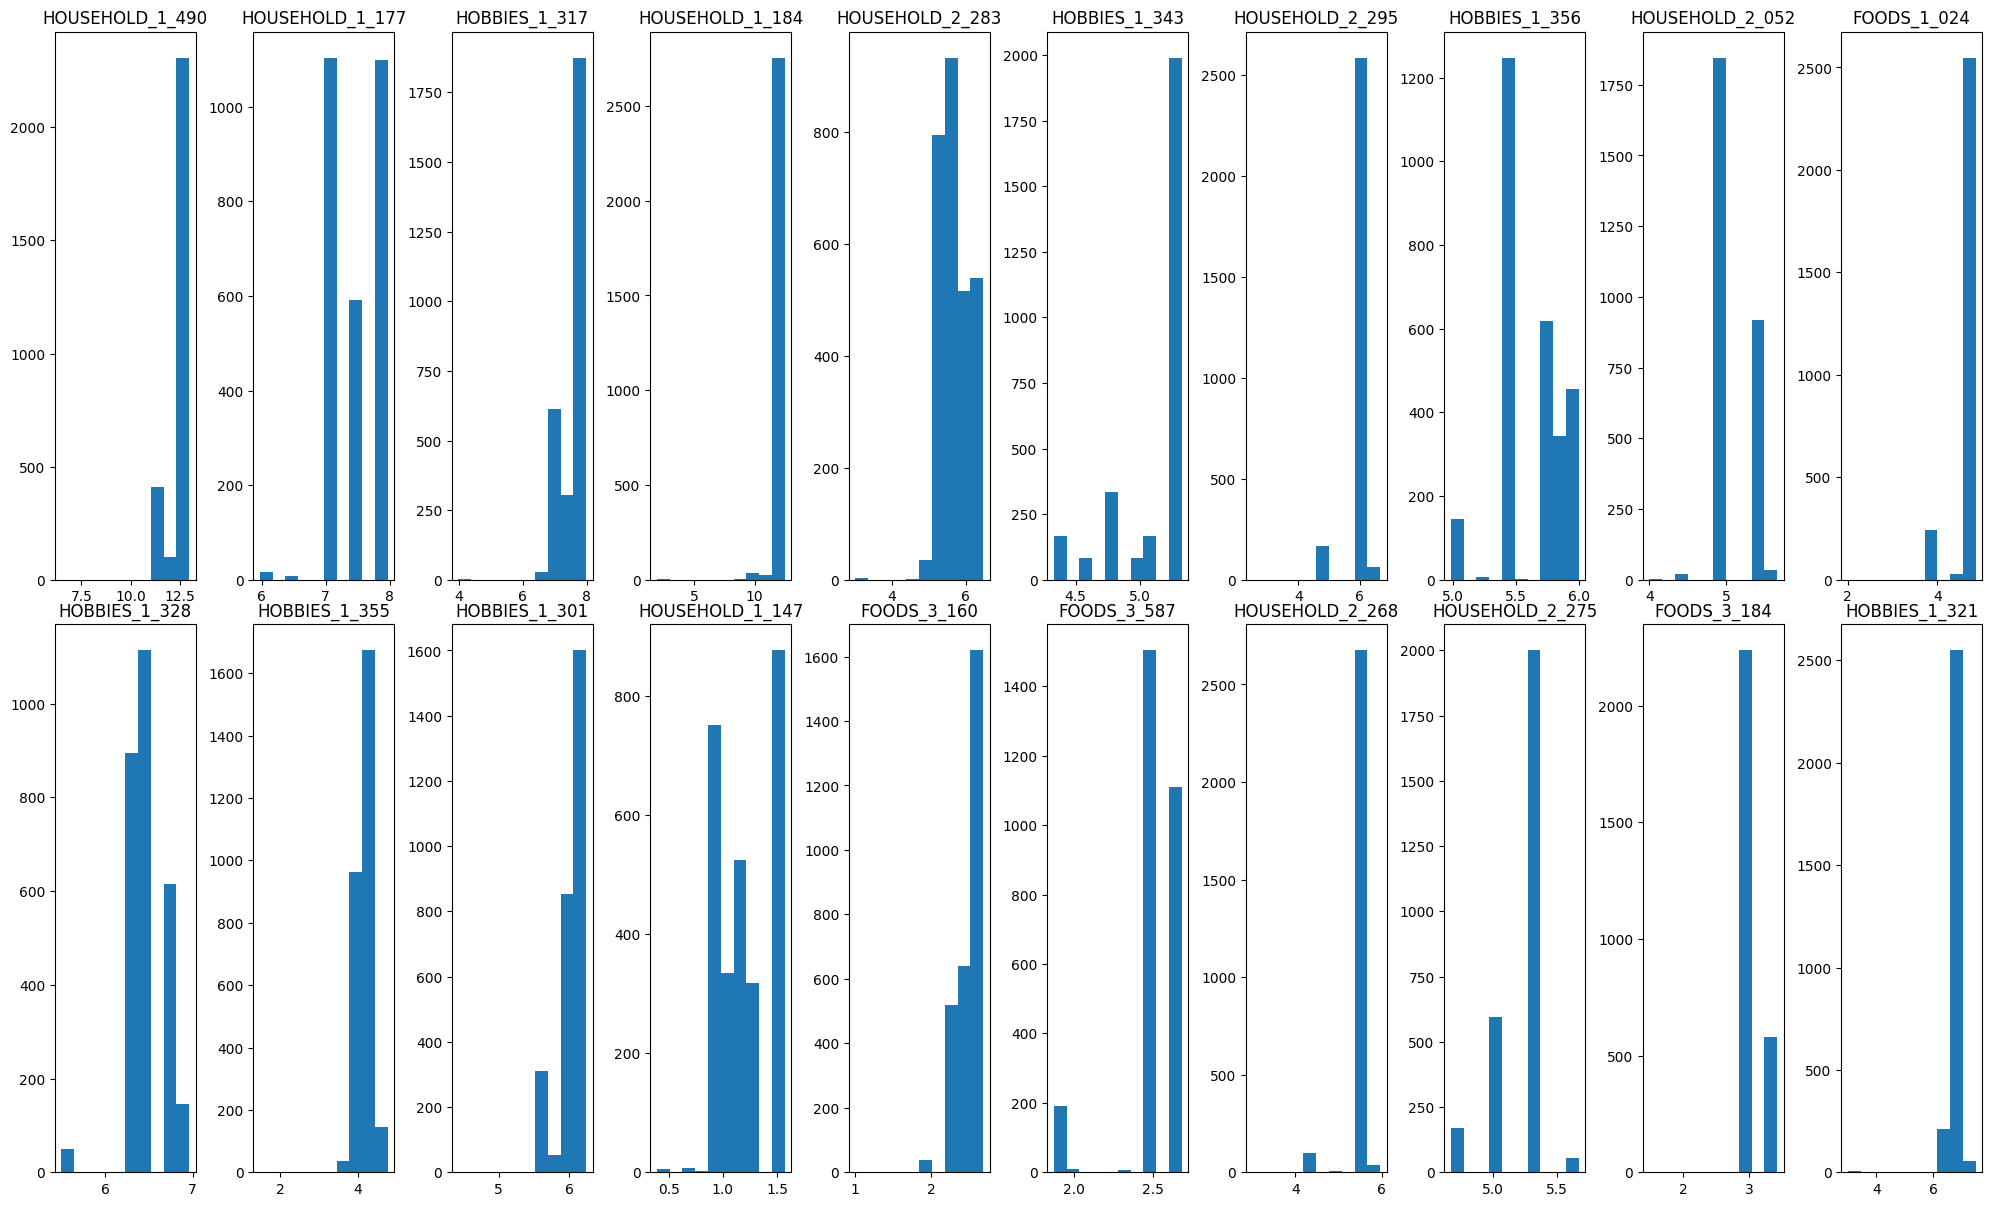

In [72]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 10)
fig.set_figwidth(20)
fig.set_figheight(12)
plt.tight_layout()

for r in range(2):
    for i in range(10):
        ax[r, i].set_title(items[10*r + i])
        ax[r, i].hist(get_prices(items[10*r+i]))

In [73]:
items_new = items[[0, 1, 2, 4, 5, 7, 10, 11, 12, 13, 14]]

In [74]:
items_new

array(['HOUSEHOLD_1_490', 'HOUSEHOLD_1_177', 'HOBBIES_1_317',
       'HOUSEHOLD_2_283', 'HOBBIES_1_343', 'HOBBIES_1_356',
       'HOBBIES_1_328', 'HOBBIES_1_355', 'HOBBIES_1_301',
       'HOUSEHOLD_1_147', 'FOODS_3_160'], dtype='<U15')

In [76]:
train_valid

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30485,FOODS_3_823_WI_3_validation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,0,0,2,2,...,2,0,0,0,0,0,1,0,0,1
30486,FOODS_3_824_WI_3_validation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
30487,FOODS_3_825_WI_3_validation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,0,6,0,2,...,2,1,0,2,0,1,0,0,1,0
30488,FOODS_3_826_WI_3_validation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,0,0,1,0,0,1,0,3,1,3


In [78]:
prices

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
...,...,...,...,...
6841116,WI_3,FOODS_3_827,11617,1.00
6841117,WI_3,FOODS_3_827,11618,1.00
6841118,WI_3,FOODS_3_827,11619,1.00
6841119,WI_3,FOODS_3_827,11620,1.00


In [82]:
calendar = pd.read_csv('data/calendar.csv')

In [83]:
calendar

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0


In [90]:
sales = train_eval.loc[train_eval['item_id'].isin(items_new)]

In [96]:
days = [col for col in sales.columns if col.startswith('d_')]
days[:5]

['d_1', 'd_2', 'd_3', 'd_4', 'd_5']

In [104]:
sales = sales.groupby('item_id')[days].sum().T

In [105]:
sales

item_id,FOODS_3_160,HOBBIES_1_301,HOBBIES_1_317,HOBBIES_1_328,HOBBIES_1_343,HOBBIES_1_355,HOBBIES_1_356,HOUSEHOLD_1_147,HOUSEHOLD_1_177,HOUSEHOLD_1_490,HOUSEHOLD_2_283
d_1,18,17,8,8,12,16,19,14,33,17,10
d_2,11,14,9,7,11,16,17,19,52,19,15
d_3,5,11,6,2,10,10,10,11,39,13,3
d_4,12,3,8,8,12,12,15,11,32,13,5
d_5,10,6,5,2,5,6,8,7,19,12,3
...,...,...,...,...,...,...,...,...,...,...,...
d_1937,5,7,4,1,1,8,5,44,0,5,2
d_1938,16,5,7,3,4,5,6,34,0,5,7
d_1939,4,11,4,6,8,9,9,28,0,5,4
d_1940,9,9,9,7,10,13,10,43,0,2,4


In [108]:
prices = prices.loc[prices['item_id'].isin(items_new)]

In [115]:
sales

item_id,FOODS_3_160,HOBBIES_1_301,HOBBIES_1_317,HOBBIES_1_328,HOBBIES_1_343,HOBBIES_1_355,HOBBIES_1_356,HOUSEHOLD_1_147,HOUSEHOLD_1_177,HOUSEHOLD_1_490,HOUSEHOLD_2_283
d_1,18,17,8,8,12,16,19,14,33,17,10
d_2,11,14,9,7,11,16,17,19,52,19,15
d_3,5,11,6,2,10,10,10,11,39,13,3
d_4,12,3,8,8,12,12,15,11,32,13,5
d_5,10,6,5,2,5,6,8,7,19,12,3
...,...,...,...,...,...,...,...,...,...,...,...
d_1937,5,7,4,1,1,8,5,44,0,5,2
d_1938,16,5,7,3,4,5,6,34,0,5,7
d_1939,4,11,4,6,8,9,9,28,0,5,4
d_1940,9,9,9,7,10,13,10,43,0,2,4


In [118]:
weeks = calendar['wm_yr_wk'].values

In [120]:
sales['week'] = weeks[:1941]

In [123]:
sales = sales.groupby('week').sum()

In [125]:
sales

item_id,FOODS_3_160,HOBBIES_1_301,HOBBIES_1_317,HOBBIES_1_328,HOBBIES_1_343,HOBBIES_1_355,HOBBIES_1_356,HOUSEHOLD_1_147,HOUSEHOLD_1_177,HOUSEHOLD_1_490,HOUSEHOLD_2_283
week,,,,,,,,,,,
11101,75,63,51,45,66,86,96,87,246,101,50
11102,91,66,54,37,79,80,50,131,226,101,34
11103,71,70,34,34,75,92,62,182,256,110,43
11104,68,70,34,39,69,52,46,118,231,103,36
11105,89,64,50,46,66,69,60,158,249,108,29
...,...,...,...,...,...,...,...,...,...,...,...
11613,71,45,30,27,31,63,47,315,1,35,26
11614,50,41,32,19,56,53,46,293,2,26,25
11615,53,44,26,20,44,46,50,231,1,27,15


In [128]:
prices

,store_id,item_id,wm_yr_wk,sell_price
67442,CA_1,HOBBIES_1_301,11101,5.62
67443,CA_1,HOBBIES_1_301,11102,5.62
67444,CA_1,HOBBIES_1_301,11103,5.62
67445,CA_1,HOBBIES_1_301,11104,5.62
67446,CA_1,HOBBIES_1_301,11105,5.62
...,...,...,...,...
6691077,WI_3,FOODS_3_160,11617,2.48
6691078,WI_3,FOODS_3_160,11618,2.48
6691079,WI_3,FOODS_3_160,11619,2.48
6691080,WI_3,FOODS_3_160,11620,2.48


In [133]:
prices = prices.pivot_table(
    index=['item_id', 'store_id'],
    columns='wm_yr_wk',
    values='sell_price'
).reset_index().drop(columns='store_id').groupby('item_id').mean().T

In [142]:
prices = prices.iloc[:278]

In [143]:
prices

item_id,FOODS_3_160,HOBBIES_1_301,HOBBIES_1_317,HOBBIES_1_328,HOBBIES_1_343,HOBBIES_1_355,HOBBIES_1_356,HOUSEHOLD_1_147,HOUSEHOLD_1_177,HOUSEHOLD_1_490,HOUSEHOLD_2_283
wm_yr_wk,,,,,,,,,,,
11101,2.470,5.68,6.790,5.732,4.752,3.720,5.108,1.42,7.97,11.570,5.47
11102,2.470,5.68,6.790,5.732,4.752,3.720,5.108,1.30,7.97,11.570,5.47
11103,2.470,5.68,6.790,5.732,4.752,3.720,5.108,1.27,7.97,11.570,5.47
11104,2.473,5.68,6.845,5.732,4.752,3.782,5.108,1.27,7.97,11.570,5.47
11105,2.480,5.68,6.980,5.732,4.752,4.029,5.108,1.27,7.97,11.570,5.47
...,...,...,...,...,...,...,...,...,...,...,...
11613,2.480,6.24,7.980,6.720,5.320,3.940,5.760,0.96,6.77,12.925,5.84
11614,2.480,6.24,7.980,6.720,5.320,3.940,5.760,0.96,6.77,12.925,5.84
11615,2.480,6.24,7.980,6.720,5.320,3.940,5.760,0.96,6.77,12.925,5.84


In [144]:
sales

item_id,FOODS_3_160,HOBBIES_1_301,HOBBIES_1_317,HOBBIES_1_328,HOBBIES_1_343,HOBBIES_1_355,HOBBIES_1_356,HOUSEHOLD_1_147,HOUSEHOLD_1_177,HOUSEHOLD_1_490,HOUSEHOLD_2_283
week,,,,,,,,,,,
11101,75,63,51,45,66,86,96,87,246,101,50
11102,91,66,54,37,79,80,50,131,226,101,34
11103,71,70,34,34,75,92,62,182,256,110,43
11104,68,70,34,39,69,52,46,118,231,103,36
11105,89,64,50,46,66,69,60,158,249,108,29
...,...,...,...,...,...,...,...,...,...,...,...
11613,71,45,30,27,31,63,47,315,1,35,26
11614,50,41,32,19,56,53,46,293,2,26,25
11615,53,44,26,20,44,46,50,231,1,27,15


In [160]:
def sell_prices(item: str):
    res = pd.concat([sales[item], prices[item]], axis=1)
    res.columns = ['sold', 'price']
    return res.groupby('price').mean().reset_index()

In [161]:
df = sell_prices('FOODS_3_160')
df

,price,sold
0,2.394,15.500000
1,2.420,82.568182
2,2.442,5.000000
3,2.450,52.500000
4,2.460,87.000000
5,2.470,63.500000
6,2.470,79.000000
7,2.473,68.000000
8,2.480,64.250000
9,2.491,45.000000


In [164]:
import statsmodels.api as sm

def elasticity(item: str):
    df = sell_prices(item)

    df['log_price'] = np.log(df['price'])
    df['log_sold'] = np.log(df['sold'])

    X = sm.add_constant(df['log_price'])  # Добавляем константу
    y = df['log_sold']

    model = sm.OLS(y, X).fit()
    res = model.params['log_price']
    return res

print(f"Эластичность спроса по цене: {elasticity('FOODS_3_160'):.2f}")

Эластичность спроса по цене: -28.22


In [168]:
elasticies = pd.DataFrame(columns=['item', 'elasticity'])

for item in items_new:
    print(f'Item: {item}')
    print(f'Elasticity: {elasticity(item):.2f}')
    elasticies.loc[len(elasticies)] = [item, np.round(elasticity(item), 2)]
    print()

Item: HOUSEHOLD_1_490
Elasticity: -16.28

Item: HOUSEHOLD_1_177
Elasticity: 23.69

Item: HOBBIES_1_317
Elasticity: -0.82

Item: HOUSEHOLD_2_283
Elasticity: -0.06

Item: HOBBIES_1_343
Elasticity: -1.22

Item: HOBBIES_1_356
Elasticity: -4.06

Item: HOBBIES_1_328
Elasticity: -3.70

Item: HOBBIES_1_355
Elasticity: -25.59

Item: HOBBIES_1_301
Elasticity: 9.50

Item: HOUSEHOLD_1_147
Elasticity: 0.27

Item: FOODS_3_160
Elasticity: -28.22



In [169]:
elasticies

,item,elasticity
0,HOUSEHOLD_1_490,-16.28
1,HOUSEHOLD_1_177,23.69
2,HOBBIES_1_317,-0.82
3,HOUSEHOLD_2_283,-0.06
4,HOBBIES_1_343,-1.22
5,HOBBIES_1_356,-4.06
6,HOBBIES_1_328,-3.70
7,HOBBIES_1_355,-25.59
8,HOBBIES_1_301,9.50
9,HOUSEHOLD_1_147,0.27


Можно сделать предположение, что *HOUSEHOLD_1_177* Вебленовский товар или товар Гиффена. Либо мы наткнулись на какой-то артефакт связанный с акциями, и из-за грубого построения средних эластичностей, получился такой аномальный результат.

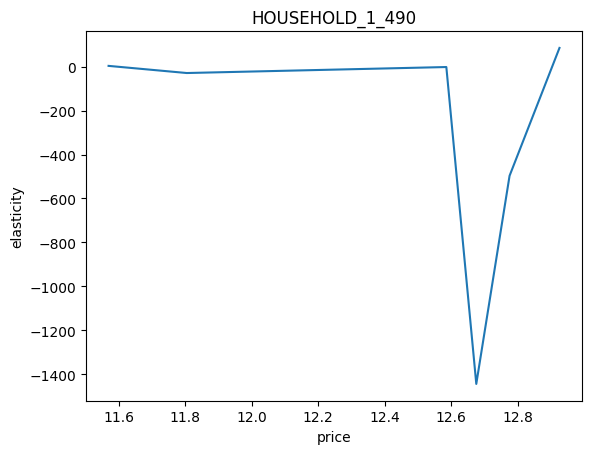

In [180]:
def elasticity_curve(item: str, ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    df = sell_prices(item)

    df['delta_price'] = df['price'].diff()
    df['delta_sold'] = df['sold'].diff()
    df['elasticity'] = (df['delta_sold'] / df['sold']) / (df['delta_price'] / df['price'])
    df = df.dropna()

    p = df['price']
    e = df['elasticity']
    ax.set_title(item)
    ax.set_ylabel('elasticity')
    ax.set_xlabel('price')

    ax.plot(p, e)

elasticity_curve('HOUSEHOLD_1_490')

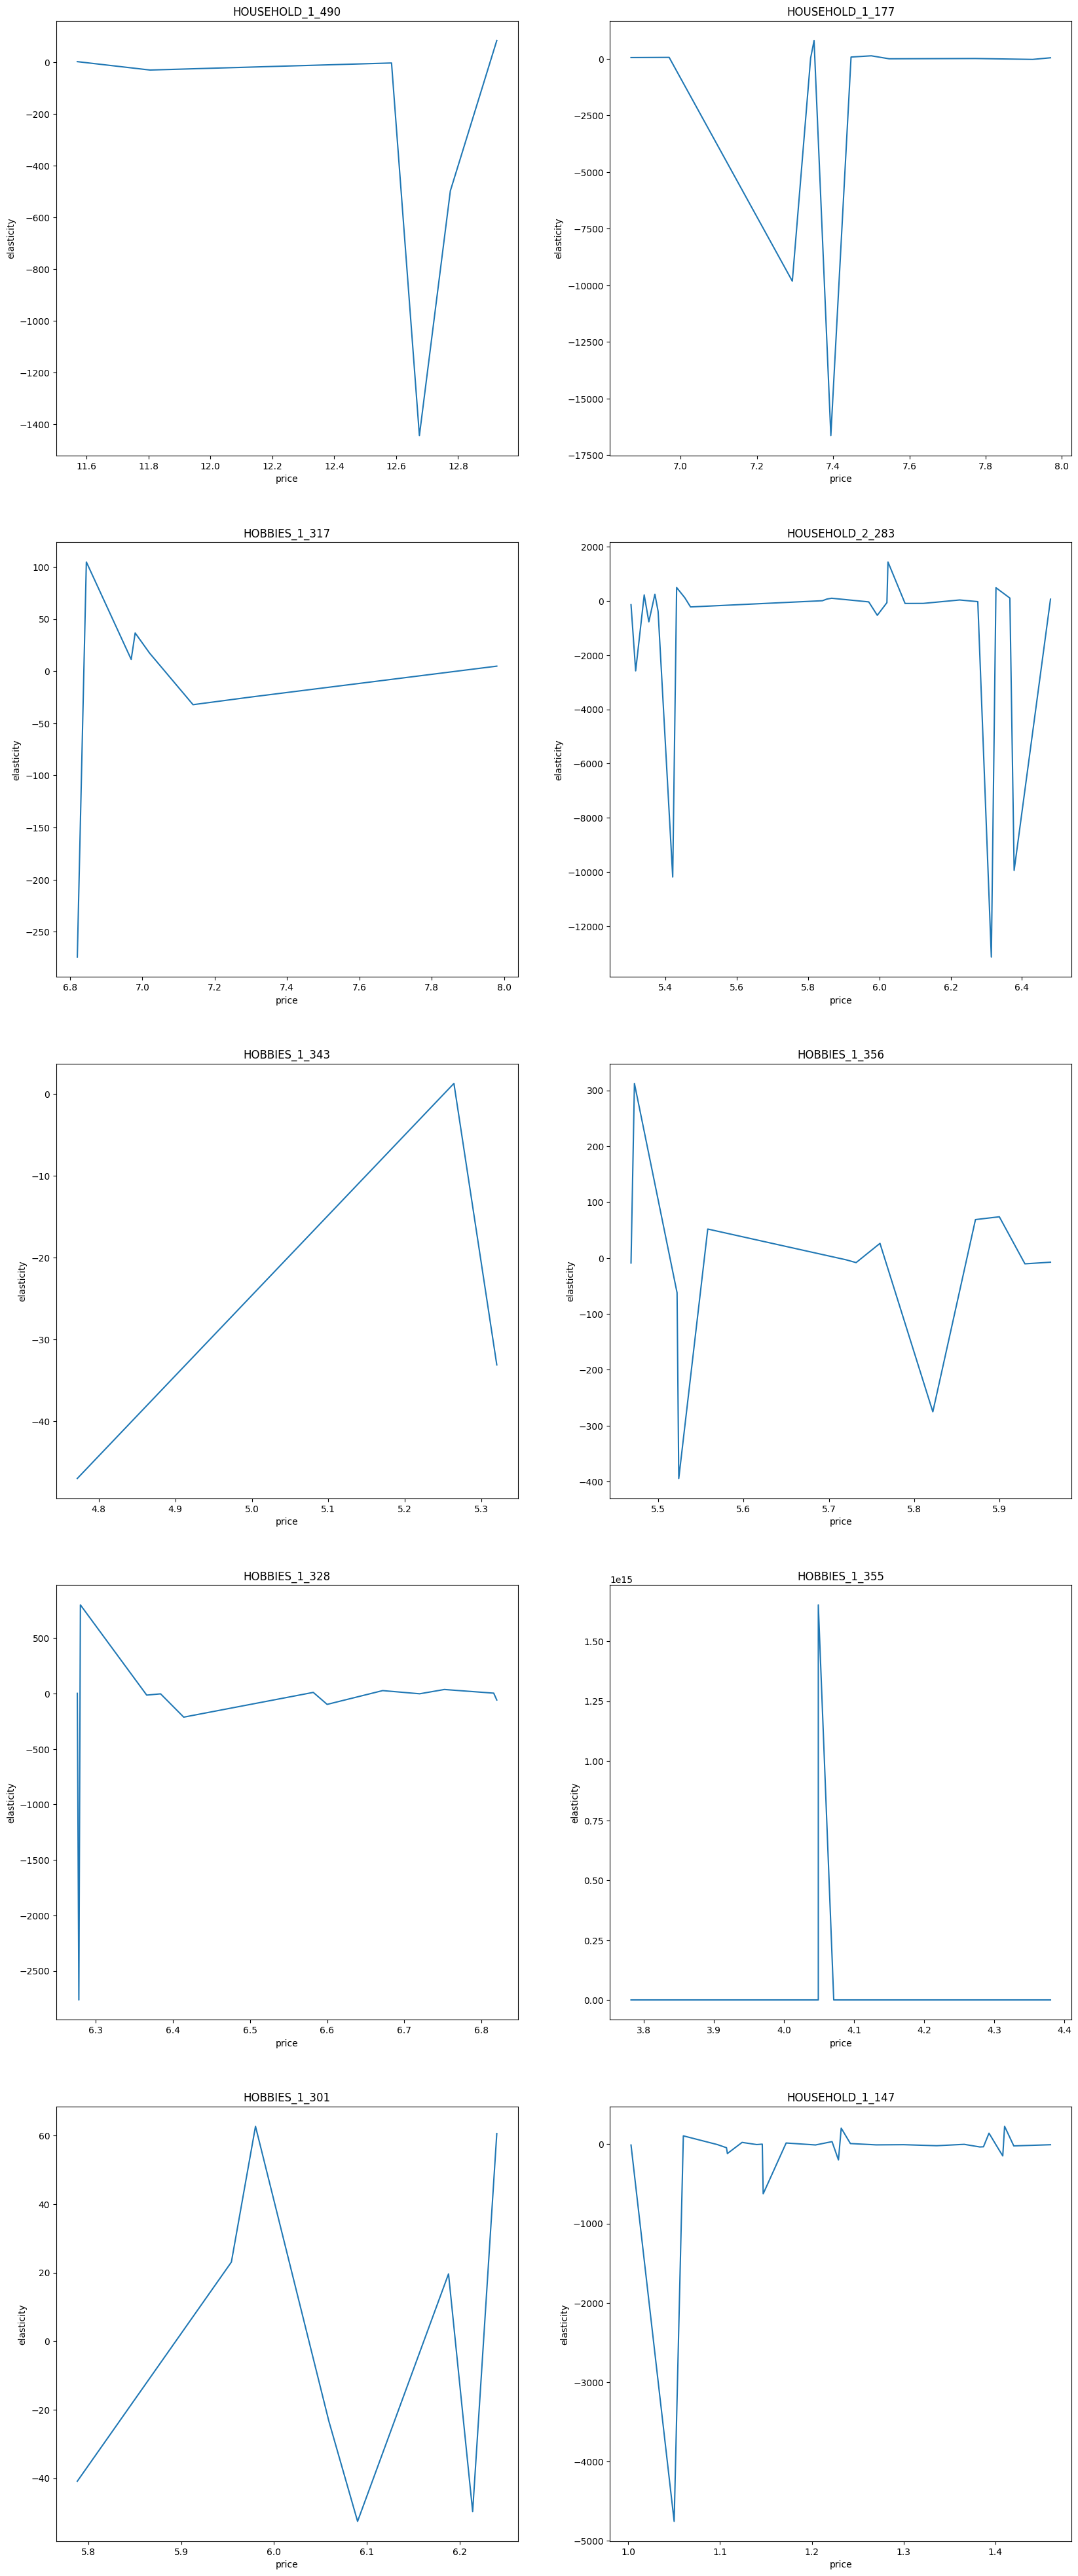

In [181]:
fig, ax = plt.subplots(5, 2)
fig.set_figwidth(20)
fig.set_figheight(5*10)

for row in range(5):
    for col in range(2):
        item = items_new[row*2 + col]
        elasticity_curve(item, ax[row, col])

Тяжело что-то содержательное сказать про эти графики, но хотя бы у нас для большинства товаров получилась отрицательная эластичность несмотря на грубое построение. Для товаров с высокой эластичностью имеет много смысла пихать их в промо, если позволяет маржинальность. Также промо может хорошо сказаться в качестве рекламы и создания лояльной аудитории, так что возможно стоит их проводить даже в небольшой минус и учитывать как маркетинговый расход. А прибыль от этого уже можно расчитать через Lightweight_MMM как нас учили в другом семинаре :)